In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import emcee
from seaborn import kdeplot
import matplotlib.pyplot as plt
from ot.lp import wasserstein_1d as wd

plt.style.use("ggplot")

In [19]:
mcmc_samps = np.load("mcmc_results/mcmc_results_10/mcmc_samps_65536_1.npy")
cond_var = np.load("mcmc_results/mcmc_results_10/cond_vars_1.npy")
rej_samps = np.load("rej_results/_10/rej_samps.npy")
cond_ys = np.load("rej_results/_10/conditioning_ys.npy")
cond_idx = np.where(cond_ys == cond_var)[0].item()
rej_samp = rej_samps[cond_idx, :]
nn_samps_ode = np.load("nn_results/ode_5/nn_samps.npy")[1::2]
ode_samp = nn_samps_ode[cond_idx, :]
nn_samps_sde = np.load("nn_sde_results/ode_5/nn_samps.npy")[1::2]
sde_samp = nn_samps_sde[cond_idx, :]

In [20]:
rej_samp

array([ 5.20821662,  5.89426835, -4.87696423, ..., -5.89904014,
       -5.72525653,  4.93158198], shape=(1500,))

In [21]:
cond_var

array([-3.72893504])

In [22]:
a = 2
b = 0.1
sigma_x = 1

def log_dens(u):
    y = cond_var
    scale = 1 / (2 * sigma_x**2)
    sum_part = (a * (y + b * (u**2 + a**2))) ** 2 + (u**2) / (a**2)
    return -scale * sum_part

In [23]:
4 ** 8

65536

In [24]:
np.random.seed(45 + 6)
initial = np.random.randn(16, 1)
nwalkers, ndim = initial.shape
nsteps = 4 ** 8 // nwalkers

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_dens)
sampler.run_mcmc(initial, nsteps, progress=True);

100%|██████████| 4096/4096 [00:00<00:00, 5185.67it/s]


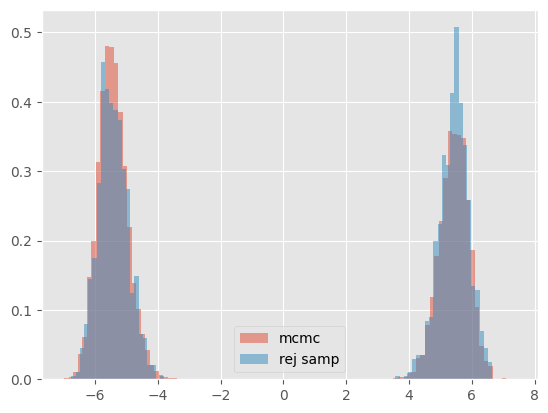

In [25]:
plt.hist(np.vstack(sampler.chain).squeeze(), label="mcmc", bins=100, density=True, alpha=0.5);
plt.hist(rej_samp, label="rej samp", bins=100, density=True, alpha=0.5)
# plt.hist(ode_samp, label="ode", bins=100, density=True, alpha=0.5)
# plt.hist(sde_samp, label="sde", bins=100, density=True, alpha=0.5)
plt.legend()

In [ ]:
wd

(1500, 1)

In [26]:
wd(np.vstack(sampler.chain), rej_samp.reshape(-1, 1))

array([0.58947993])

In [15]:
rej_samp

array([], shape=(0, 1500), dtype=float64)

<Axes: ylabel='Density'>

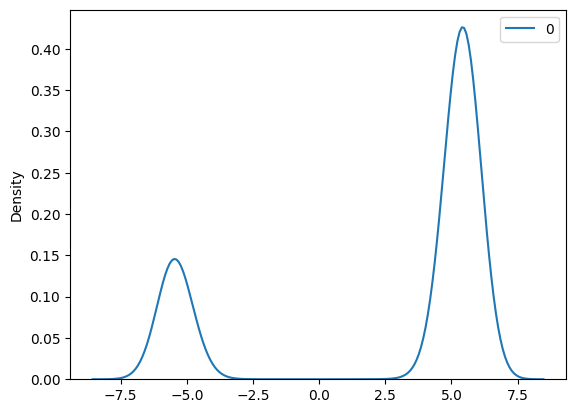

In [28]:
kdeplot(mcmc_samps)

In [29]:
cond_var

array([-2.87572413])

In [1]:
1024 * 16

16384

In [21]:
subsamps = sampler.chain
subsamps[:2, 0, :].shape

(2, 1)

<Axes: ylabel='Density'>

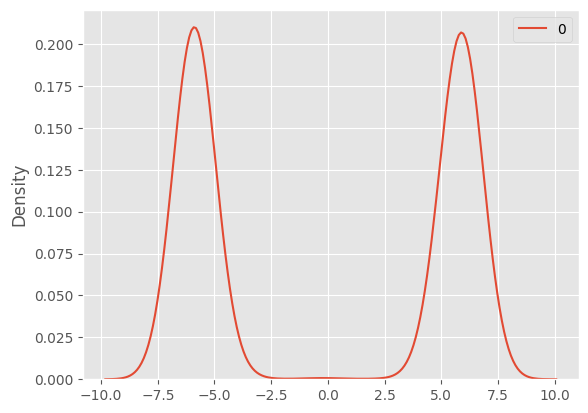

In [45]:
sample_no = 1024 * 16
kdeplot(subsamps[:, : sample_no // 4, :].reshape(sample_no, 1))

In [31]:
subsamps[:, : int(8 / 4), :].reshape(8, 1)

array([[-0.08560268],
       [-0.09682984],
       [ 0.55577697],
       [ 0.40317729],
       [-0.3506484 ],
       [-0.3427189 ],
       [-0.16132231],
       [-0.13489303]])

In [27]:
subsamps

array([[[-0.08560268],
        [-0.09682984],
        [-0.10061418],
        ...,
        [ 5.48761235],
        [ 5.48761235],
        [ 5.48761235]],

       [[ 0.55577697],
        [ 0.40317729],
        [ 0.28242175],
        ...,
        [ 5.36808654],
        [ 5.36808654],
        [ 5.36808654]],

       [[-0.3506484 ],
        [-0.3427189 ],
        [-0.11502151],
        ...,
        [-6.28924671],
        [-6.28924671],
        [-6.28924671]],

       [[-0.16132231],
        [-0.13489303],
        [-0.64932634],
        ...,
        [-5.23728103],
        [-5.23728103],
        [-5.23728103]]], shape=(4, 25000, 1))